# Sentiment Analysis with DistilBERT

In this notebook, we implement a Transformer-based sentiment classifier using DistilBERT.

We train and evaluate the model on three different datasets:
- 1K Amazon Reviews
- 25K Amazon Reviews
- Video Game Reviews

Each dataset is processed and evaluated independently using the same pipeline.

## Setup & Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from utils import device_check
from utils_BERT import (
    save_bert_run,
    build_bert_loaders,
    fit_bert,
    evaluate_bert,
    plot_confusion_matrix_bert,
)

device = device_check()


PyTorch: 2.11.0+cpu | Python: 3.13.7 | OS: Windows 11
CUDA available: False
Using cpu


In [ ]:
LOG_WANDB = False
NUM_WORKERS = min(4, os.cpu_count() or 0)
WANDB_DIR  = Path(__file__).parent.parent
SPLITS_DIR = Path(__file__).parent.parent / 'data' / 'splits'

PIN_MEMORY = True
SEED = 1

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

---
## Initial Test — 1K Amazon Reviews

### Load Pre-split Data

In [ ]:
train_df = pd.read_csv(SPLITS_DIR / "1k_train.csv")
val_df = pd.read_csv(SPLITS_DIR / "1k_val.csv")
test_df = pd.read_csv(SPLITS_DIR / "1k_test.csv")

text_col = "Sentence"
label_col = "Class"

NUM_LABELS = 2
NUM_CLASSES = 2

### Tokenizer & DataLoaders

We tokenize the text and build DataLoaders from the pre-split CSV files.

In [4]:
BATCH_SIZE = 16

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

loaders = build_bert_loaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

### Model

We fine-tune a pre-trained DistilBERT model for binary sentiment classification.

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

model.to(device)

LEARNING_RATE = 2e-5

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training

The model is trained on the training split and validated after every epoch. The best checkpoint is restored automatically based on validation loss.

In [ ]:
NUM_EPOCHS = 5

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

wandb_kwargs = dict(
    entity='d7047e-group12',
    project='Lab1',
    name='DistilBERT 1K',
    tags=['Task 1.2', 'DistilBERT', 'Transformer', '1K'],
    dir=WANDB_DIR,
    config={
        'dataset': 'Amazon 1K',
        'model_name': MODEL_NAME,
        'optimizer': optimizer,
        'lr': LEARNING_RATE,
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'max_length': MAX_LENGTH,
        'warmup_ratio': 0.1,
    },
)

_ = fit_bert(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    scheduler=scheduler,
    wandb_kwargs=wandb_kwargs,
    log=LOG_WANDB,
)

_ = save_bert_run(
    out_dir='../models/distilbert_1k',
    model=model,
    model_name=MODEL_NAME,
    num_labels=NUM_LABELS,
    max_length=MAX_LENGTH,
)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: hamid-sabeti (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
1/3 |     0.4397 |     82.10% |     0.2452 |     92.22%
2/3 |     0.1648 |     94.94% |     0.2444 |     91.11%
3/3 |     0.0915 |     97.41% |     0.3282 |     87.78%


Training Accuracy,▁▇█
Training Loss,█▂▁
Validation Accuracy,█▆▁
Validation Loss,▁▁█
Training Accuracy,97.40741
Training Loss,0.09147
Validation Accuracy,87.77778
Validation Loss,0.32825



Restored best weights (val loss 0.2444)


### Test-Set Evaluation & Confusion Matrix

The final result is reported on the held-out test set for fair comparison with the other models.

[DistilBERT-1K] Test loss: 0.2267 | Test acc: 93.00%


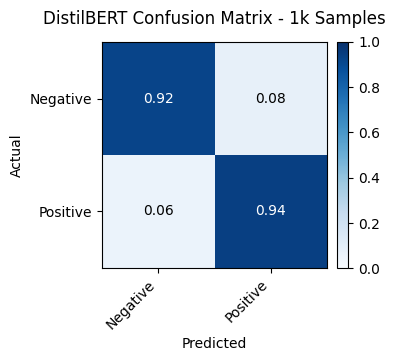

In [ ]:
_ = evaluate_bert(
    model,
    test_loader,
    criterion,
    label="DistilBERT-1K",
    class_names=["Negative", "Positive"],
)

In [ ]:
plot_confusion_matrix_bert(
    model,
    test_loader,
    NUM_CLASSES,
    ["Negative", "Positive"],
    "DistilBERT Confusion Matrix — 1K Samples",
    normalize=True,
)

---
## Scaling Up — 25K Amazon Reviews

### Load Pre-split Data

In [8]:
train_df = pd.read_csv(SPLITS_DIR / "25k_train.csv")
val_df = pd.read_csv(SPLITS_DIR / "25k_val.csv")
test_df = pd.read_csv(SPLITS_DIR / "25k_test.csv")

text_col = "Sentence"
label_col = "Class"

NUM_LABELS = 2
NUM_CLASSES = 2

### Tokenizer & DataLoaders

In [ ]:
BATCH_SIZE = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

loaders = build_bert_loaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

### Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

model.to(device)

LEARNING_RATE = 2e-5

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training

In [ ]:
NUM_EPOCHS = 5

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

wandb_kwargs = dict(
    entity='d7047e-group12',
    project='Lab1',
    name='DistilBERT 25K',
    tags=['Task 1.2', 'DistilBERT', 'Transformer', '25K'],
    dir=WANDB_DIR,
    config={
        'dataset': 'Amazon 25K',
        'model_name': MODEL_NAME,
        'optimizer': optimizer,
        'lr': LEARNING_RATE,
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'max_length': MAX_LENGTH,
        'warmup_ratio': 0.1,
    },
)

_ = fit_bert(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    scheduler=scheduler,
    wandb_kwargs=wandb_kwargs,
    log=LOG_WANDB,
)

_ = save_bert_run(
    out_dir='../models/distilbert_25k',
    model=model,
    model_name=MODEL_NAME,
    num_labels=NUM_LABELS,
    max_length=MAX_LENGTH,
)

### Test-Set Evaluation & Confusion Matrix

[DistilBERT-25K] Test loss: 0.2059 | Test acc: 92.36%


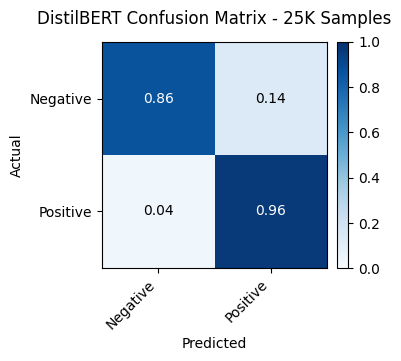

In [ ]:
_ = evaluate_bert(
    model,
    test_loader,
    criterion,
    label="DistilBERT-25K",
    class_names=["Negative", "Positive"],
)

In [ ]:
plot_confusion_matrix_bert(
    model,
    test_loader,
    NUM_CLASSES,
    ["Negative", "Positive"],
    "DistilBERT Confusion Matrix — 25K Samples",
    normalize=True,
)

---
## Video Game Reviews — 5-Class Rating

### Load Pre-split Data

In [13]:
train_df = pd.read_csv(SPLITS_DIR / "vg_train.csv")
val_df = pd.read_csv(SPLITS_DIR / "vg_val.csv")
test_df = pd.read_csv(SPLITS_DIR / "vg_test.csv")

text_col = "Sentence"
label_col = "Class"

# Convert labels from 1-5 → 0-4
train_df[label_col] = train_df[label_col].astype(int) - 1
val_df[label_col] = val_df[label_col].astype(int) - 1
test_df[label_col] = test_df[label_col].astype(int) - 1

NUM_LABELS = 5
NUM_CLASSES = 5

### Tokenizer & DataLoaders

In [ ]:
BATCH_SIZE = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

loaders = build_bert_loaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

### Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

model.to(device)

LEARNING_RATE = 2e-5
LABEL_SMOOTHING = 0.1

# Inverse-frequency class weights to counter the ~58% 5-star imbalance
class_counts = np.bincount(np.asarray(train_df[label_col], dtype=np.int64))
class_weights = torch.tensor(
    (1.0 / class_counts) / (1.0 / class_counts).sum() * len(class_counts),
    dtype=torch.float, device=device,
)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training

In [ ]:
NUM_EPOCHS = 5

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

wandb_kwargs = dict(
    entity='d7047e-group12',
    project='Lab1',
    name='DistilBERT VG',
    tags=['Task 1.2', 'DistilBERT', 'Transformer', 'VG'],
    dir=WANDB_DIR,
    config={
        'dataset': 'Video Games',
        'model_name': MODEL_NAME,
        'optimizer': optimizer,
        'lr': LEARNING_RATE,
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'max_length': MAX_LENGTH,
        'warmup_ratio': 0.1,
        'label_smoothing': LABEL_SMOOTHING,
        'class_weights': class_weights.tolist(),
    },
)

_ = fit_bert(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    scheduler=scheduler,
    wandb_kwargs=wandb_kwargs,
    log=LOG_WANDB,
)

_ = save_bert_run(
    out_dir='../models/distilbert_vg',
    model=model,
    model_name=MODEL_NAME,
    num_labels=NUM_LABELS,
    max_length=MAX_LENGTH,
)

### Test-Set Evaluation & Confusion Matrix

[DistilBERT-VG] Test loss: 0.6198 | Test acc: 75.88%


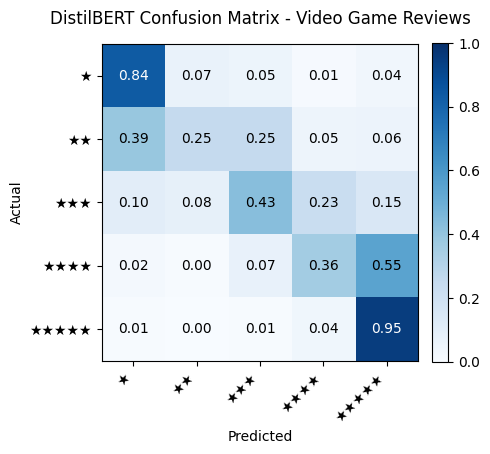

In [ ]:
_ = evaluate_bert(
    model,
    test_loader,
    criterion,
    label="DistilBERT-VG",
    class_names=['★', '★★', '★★★', '★★★★', '★★★★★'],
)

In [ ]:
plot_confusion_matrix_bert(
    model,
    test_loader,
    NUM_CLASSES,
    ['★', '★★', '★★★', '★★★★', '★★★★★'],
    "DistilBERT Confusion Matrix — Video Game Reviews",
    normalize=True,
)